<a href="https://colab.research.google.com/github/jbcvasconcelos/aula3/blob/main/An%C3%A1lise_Expo_ENCCEJA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aprovação do Encceja 2023 e 2024 **

In [ ]:
import pandas as pd # Manipulação de dados tabulares (como planilhas do Excel ou tabelas de SQL)
import matplotlib.pyplot as plt   # Serve para criar o esqueleto dos gráficos (eixos, títulos, tamanhos)
import seaborn as sns # Cria gráficos elegantes (como mapas de calor ou distribuições)
from google.colab import drive

drive.mount('/content/drive') # Montar o Drive para acessar os arquivos

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/encceja2024/DADOS/ #a pasta que escolhemos para analise em nosso projeto foi (ENCCEJA_2024_REG_NAC)
#############################################Aqui estão as notas, as faixas etárias, o sexo e o estado (UF) de todos os inscritos do Brasil.

MICRODADOS_ENCCEJA_2024_ITENS_PROVA.csv
MICRODADOS_ENCCEJA_2024_PPL_NAC.csv
MICRODADOS_ENCCEJA_2024_PPL_NAC_QSE.csv
MICRODADOS_ENCCEJA_2024_REG_NAC.csv


In [ ]:
print("--- Primeiras 5 linhas do arquivo ---")  # TEM DE 118 COLUNAS
df_24 = pd.read_csv('/content/drive/MyDrive/encceja2024/DADOS/MICRODADOS_ENCCEJA_2024_REG_NAC.csv', sep=';', encoding='latin1')
display(df_24.head())
total_colunas = len(df_24.columns) # CONATAR A QUANTIDADE DE COLUNAS
print(total_colunas)

--- Primeiras 5 linhas do arquivo ---


,NU_INSCRICAO,NU_ANO,TP_CERTIFICACAO,TP_FAIXA_ETARIA,TP_SEXO,CO_UF_PROVA,SG_UF_PROVA,NO_ENTIDADE_CERTIFICADORA,IN_PROVA_LC,IN_PROVA_CH,...,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,Q74,Q75
0,210007212347,2024,2,11,M,15,PA,SECRETARIA DE ESTADO DA EDUCAÇÃO PARÁ,1,1,...,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,210007350189,2024,2,13,M,42,SC,SECRETARIA DE ESTADO DA EDUCAÇÃO SANTA CATARINA,1,1,...,A,A,C,A,A,B,A,B,A,B
2,210007490150,2024,2,11,M,50,MS,SECRETARIA DE ESTADO DA EDUCAÇÃO MATO GROSSO D...,1,1,...,A,A,A,A,A,A,A,A,A,A
3,210007309651,2024,2,17,F,35,SP,SECRETARIA DE ESTADO DA EDUCAÇÃO SÃO PAULO,1,1,...,A,A,C,A,B,B,A,B,A,B
4,210007007898,2024,2,5,F,50,MS,INSTITUTO FEDERAL DE MATO GROSSO DO SUL,0,0,...,B,B,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN


118


In [ ]:
# Seleciona apenas as colunas de identificação e as notas
colunas_notas = ['NU_INSCRICAO', 'SG_UF_PROVA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO','TP_SEXO']

# Mostra as primeiras 10 linhas dessas colunas
display(df_24[colunas_notas].head(10))

,NU_INSCRICAO,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_SEXO
0,210007212347,PA,NaN,NaN,NaN,NaN,NaN,M
1,210007350189,SC,139.0,134.0,118.0,152.0,7.6,M
2,210007490150,MS,NaN,NaN,NaN,NaN,NaN,M
3,210007309651,SP,119.0,119.0,111.0,111.0,5.4,F
4,210007007898,MS,NaN,NaN,NaN,90.0,NaN,F
5,210007268173,PB,NaN,NaN,NaN,NaN,NaN,M
6,210007279397,PA,NaN,NaN,NaN,NaN,NaN,M
7,210007484475,RJ,117.0,106.0,89.0,85.0,0.0,M
8,210007035682,SP,NaN,NaN,NaN,NaN,NaN,M
9,210006681552,BA,122.0,115.0,120.0,98.0,7.2,F


In [ ]:
def processar_encceja(caminho, ano):
    print(f"--- Iniciando processamento de {ano} ---")

    colunas_essenciais = [
        'SG_UF_PROVA', 'TP_SEXO', 'TP_FAIXA_ETARIA',
        'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'
    ]

    # Lendo o CSV
    df = pd.read_csv(caminho, sep=';', encoding='latin1', usecols=colunas_essenciais)

    # 1. Criando as colunas de aprovação individualmente
    df['APROVADO_CN'] = df['NU_NOTA_CN'].fillna(0) >= 100
    df['APROVADO_CH'] = df['NU_NOTA_CH'].fillna(0) >= 100
    df['APROVADO_LC'] = df['NU_NOTA_LC'].fillna(0) >= 100
    df['APROVADO_MT'] = df['NU_NOTA_MT'].fillna(0) >= 100
    df['APROVADO_RED'] = df['NU_NOTA_REDACAO'].fillna(0) >= 5

    # 2. Regra de Aprovação Geral: True se passou em TODAS as frentes
    # Usamos o método .all(axis=1) para verificar se todas as colunas de aprovação são True
    colunas_aprovacao = ['APROVADO_CN', 'APROVADO_CH', 'APROVADO_LC', 'APROVADO_MT', 'APROVADO_RED']
    df['RESULTADO_BOOL'] = df[colunas_aprovacao].all(axis=1)

    # Tradução para texto
    df['RESULTADO'] = df['RESULTADO_BOOL'].map({True: 'APROVADO', False: 'REPROVADO'})

    df['ANO'] = ano

    # 3. Tradução Amigável da Faixa Etária
    def categorizar_idade(cod):
        if cod <= 4: return '15-19 anos'
        elif cod <= 10: return '20-29 anos'
        elif cod <= 15: return '30-49 anos'
        else: return '50+ anos'

    df['CATEGORIA_IDADE'] = df['TP_FAIXA_ETARIA'].apply(categorizar_idade)

    # Opcional: Remover a coluna auxiliar booleana antes de retornar
    df.drop(columns=['RESULTADO_BOOL'], inplace=True)

    return df

In [ ]:
# CAMINHO QUE VAMOS TRABALHAR
path_23 = '/content/drive/MyDrive/encceja2023/DADOS/MICRODADOS_ENCCEJA_2023_REG_NAC.csv'
path_24 = '/content/drive/MyDrive/encceja2024/DADOS/MICRODADOS_ENCCEJA_2024_REG_NAC.csv'

# Criando os DataFrames
df_23 = processar_encceja(path_23, 2023)
df_24 = processar_encceja(path_24, 2024)

# Unindo os dois para facilitar a comparação lado a lado
df_total = pd.concat([df_23, df_24])
print("Processamento concluído!")

--- Iniciando processamento de 2023 ---
--- Iniciando processamento de 2024 ---
Processamento concluído!


In [ ]:
print("\n--- Informações de Colunas e Tipos de Dados ---")
df_24.info()


--- Informações de Colunas e Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834648 entries, 0 to 834647
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TP_FAIXA_ETARIA  834648 non-null  int64  
 1   TP_SEXO          834648 non-null  object 
 2   SG_UF_PROVA      834648 non-null  object 
 3   NU_NOTA_LC       204915 non-null  float64
 4   NU_NOTA_CH       187994 non-null  float64
 5   NU_NOTA_MT       242560 non-null  float64
 6   NU_NOTA_CN       182842 non-null  float64
 7   NU_NOTA_REDACAO  204915 non-null  float64
 8   APROVADO_CN      834648 non-null  bool   
 9   APROVADO_CH      834648 non-null  bool   
 10  APROVADO_LC      834648 non-null  bool   
 11  APROVADO_MT      834648 non-null  bool   
 12  APROVADO_RED     834648 non-null  bool   
 13  RESULTADO        834648 non-null  object 
 14  ANO              834648 non-null  int64  
 15  CATEGORIA_IDADE  834648 non-null  ob

In [ ]:
print(df_23.isnull().sum()) # INDENTIFICAR OS VALORES NULOS

TP_FAIXA_ETARIA         0
TP_SEXO                 0
SG_UF_PROVA             0
NU_NOTA_LC         803383
NU_NOTA_CH         831917
NU_NOTA_MT         768803
NU_NOTA_CN         833716
NU_NOTA_REDACAO    803384
APROVADO_CN             0
APROVADO_CH             0
APROVADO_LC             0
APROVADO_MT             0
APROVADO_RED            0
RESULTADO               0
ANO                     0
CATEGORIA_IDADE         0
dtype: int64


In [ ]:
# Remove linhas onde qualquer uma das notas seja nula
# Limpa os dados de 2023
df_23_limpo = df_23.dropna(subset=['NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_MT', 'NU_NOTA_CN', 'NU_NOTA_REDACAO'])

# Limpa os dados de 2024
df_24_limpo = df_24.dropna(subset=['NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_MT', 'NU_NOTA_CN', 'NU_NOTA_REDACAO'])

print(df_24_limpo.isnull().sum())

TP_FAIXA_ETARIA    0
TP_SEXO            0
SG_UF_PROVA        0
NU_NOTA_LC         0
NU_NOTA_CH         0
NU_NOTA_MT         0
NU_NOTA_CN         0
NU_NOTA_REDACAO    0
APROVADO_CN        0
APROVADO_CH        0
APROVADO_LC        0
APROVADO_MT        0
APROVADO_RED       0
RESULTADO          0
ANO                0
CATEGORIA_IDADE    0
dtype: int64


In [ ]:
print(f"Linhas antes: {len(df_24)}") # atualização de linhas
df_presentes = df_24.dropna(subset=['NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_MT', 'NU_NOTA_CN', 'NU_NOTA_REDACAO'])
print(f"Linhas depois: {len(df_presentes)}")

#Ciências da to	Química, Física e Biologia. Ciências Humanas	História, Geografia, Filosofia e Sociologia.
#Linguagens e Códigos	Língua Portuguesa, Língua Estrangeira, Artes e Educação Física. matematica

Linhas antes: 834648
Linhas depois: 161004


In [ ]:
# --- A. ESTATÍSTICA DE SEXO E IDADE (COM DIFERENÇA) ---
print("\n" + "="*70)
print("TAXA DE APROVAÇÃO (%) POR SEXO E FAIXA ETÁRIA (DIFERENÇA F vs M)")
print("="*70)

# 1. Cria a tabela base
tabela_perfil = df_total.pivot_table(
    index=['ANO', 'CATEGORIA_IDADE'],
    columns='TP_SEXO',
    values='RESULTADO',
    aggfunc=lambda x: (x == 'APROVADO').mean() * 100
)

# 2. Calcula a diferença

tabela_perfil['DIFERENCA_PP'] = (tabela_perfil['F'] - tabela_perfil['M']).round(2)

# Arredonda o restante da tabela para exibição
tabela_perfil = tabela_perfil.round(2)

# 3. Exibe o resultado
print(tabela_perfil)
print("\n*DIFERENCA_PP: Pontos percentuais de vantagem masculina sobre a femenina.")


TAXA DE APROVAÇÃO (%) POR SEXO E FAIXA ETÁRIA (DIFERENÇA F vs M)
TP_SEXO                   F      M  DIFERENCA_PP
ANO  CATEGORIA_IDADE                            
2023 15-19 anos       12.88  15.90         -3.01
     20-29 anos        7.59  11.28         -3.69
     30-49 anos        7.55  10.97         -3.42
     50+ anos          6.61  11.69         -5.08
2024 15-19 anos       17.78  20.45         -2.67
     20-29 anos       10.94  14.25         -3.31
     30-49 anos        9.98  13.17         -3.19
     50+ anos          8.58  12.75         -4.17

*DIFERENCA_PP: Pontos percentuais de vantagem masculina sobre a femenina.


In [ ]:
# --- B. DESEMPENHO EM TODOS OS ESTADOS DO BRASIL (2023) ---

print("\n" + "="*60)
print("DESEMPENHO: TODOS OS ESTADOS (2023)")
print("="*60)

# Agrupamos por estado e calculamos a porcentagem do resultado
tabela_brasil_2023 = df_23.groupby('SG_UF_PROVA')['RESULTADO'].value_counts(normalize=True).unstack() * 100

# 2. Exibe o resultado de todos os estados, ordenados pela maior taxa de aprovação
# O .round(2) deixa as porcentagens com duas casas decimais
print(tabela_brasil_2023.sort_values(by='APROVADO', ascending=False).round(2))

# 3. Opcional: Ver quantos estados foram processados
print(f"\nTotal de estados analisados: {len(tabela_brasil_2023)}")


DESEMPENHO: TODOS OS ESTADOS (2023)
RESULTADO    APROVADO  REPROVADO
SG_UF_PROVA                     
SC              13.94      86.06
PE              12.73      87.27
PR              12.52      87.48
RS              12.05      87.95
RN              11.55      88.45
MG              11.52      88.48
PB              10.47      89.53
SP              10.26      89.74
BA               9.60      90.40
PI               9.47      90.53
AL               9.13      90.87
RJ               8.96      91.04
DF               8.75      91.25
ES               8.71      91.29
CE               8.71      91.29
GO               8.58      91.42
SE               7.81      92.19
MS               7.07      92.93
MA               6.52      93.48
PA               6.30      93.70
MT               6.19      93.81
TO               5.80      94.20
AP               5.39      94.61
RO               5.00      95.00
RR               4.72      95.28
AC               3.95      96.05
AM               2.89      97.11

Total

In [ ]:
# --- B. DESEMPENHO EM TODOS OS ESTADOS DO BRASIL (2024) ---

print("\n" + "="*60)
print("DESEMPENHO: TODOS OS ESTADOS (2024)")
print("="*60)

# Agrupamos por estado e calculamos a porcentagem do resultado
tabela_brasil_2024 = df_24.groupby('SG_UF_PROVA')['RESULTADO'].value_counts(normalize=True).unstack() * 100

# 2. Exibe o resultado de todos os estados, ordenados pela maior taxa de aprovação
# O .round(2) deixa as porcentagens com duas casas decimais
print(tabela_brasil_2024.sort_values(by='APROVADO', ascending=False).round(2))

# 3. Opcional: Ver quantos estados foram processados
print(f"\nTotal de estados analisados: {len(tabela_brasil_2024)}")


DESEMPENHO: TODOS OS ESTADOS (2024)
RESULTADO    APROVADO  REPROVADO
SG_UF_PROVA                     
SC              17.51      82.49
PR              15.81      84.19
PE              15.42      84.58
MG              14.17      85.83
RN              13.88      86.12
RS              13.23      86.77
SP              13.09      86.91
ES              12.37      87.63
PB              12.31      87.69
AL              12.09      87.91
RJ              12.07      87.93
DF              11.52      88.48
BA              11.41      88.59
CE              11.19      88.81
SE              11.17      88.83
PI              11.12      88.88
GO              11.10      88.90
MS               9.39      90.61
RO               8.52      91.48
MT               8.34      91.66
PA               8.20      91.80
MA               8.06      91.94
TO               7.60      92.40
AP               7.47      92.53
RR               6.58      93.42
AC               5.74      94.26
AM               4.38      95.62

Total

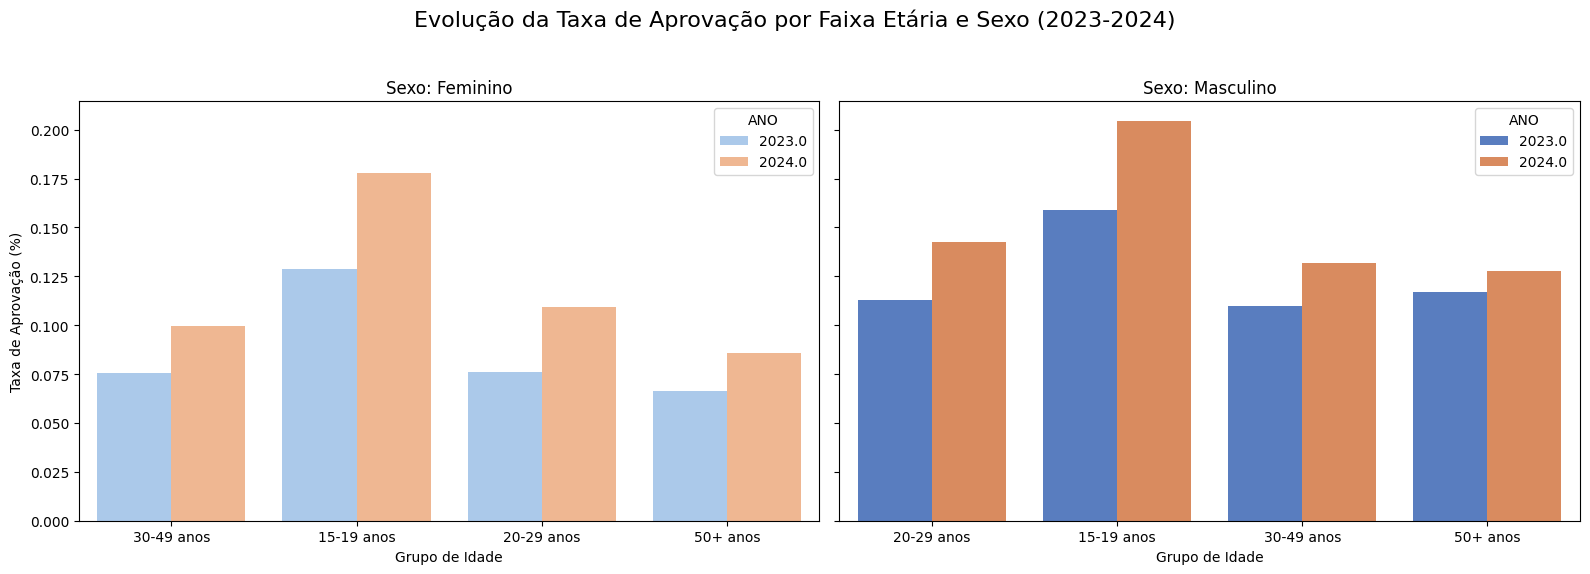


DESTAQUES REGIONAIS: DESEMPENHO ACUMULADO (2023 + 2024)
🏆 ESTADO COM MELHOR DESEMPENHO GERAL: SC
   Taxa de Aprovação Média: 15.51%
------------------------------
🚨 ESTADO COM PIOR DESEMPENHO GERAL:  AM
   Taxa de Aprovação Média: 3.43%


In [ ]:
# --- C. NOVA VISUALIZAÇÃO GERAL: IDADE, ANO E SEXO ---
df_total_grafico = pd.concat([df_23, df_24], ignore_index=True) # concat	Unir os anos de 2023 e 2024.

# Prepara a figura com dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Evolução da Taxa de Aprovação por Faixa Etária e Sexo (2023-2024)', fontsize=16)

# Gráfico 1: Feminino
# Substituído ci=None por errorbar=None para evitar o aviso de FutureWarning
sns.barplot(ax=axes[0], data=df_total_grafico[df_total_grafico['TP_SEXO'] == 'F'],
            x='CATEGORIA_IDADE', y=(df_total_grafico['RESULTADO'] == 'APROVADO'),
            hue='ANO', errorbar=None, palette='pastel')
axes[0].set_title('Sexo: Feminino')
axes[0].set_ylabel('Taxa de Aprovação (%)')
axes[0].set_xlabel('Grupo de Idade')

# Gráfico 2: Masculino
sns.barplot(ax=axes[1], data=df_total_grafico[df_total_grafico['TP_SEXO'] == 'M'],  #barplot	Gerar uma comparação visual entre os grupos.
            x='CATEGORIA_IDADE', y=(df_total_grafico['RESULTADO'] == 'APROVADO'),
            hue='ANO', errorbar=None, palette='muted')
axes[1].set_title('Sexo: Masculino')
axes[1].set_ylabel('')
axes[1].set_xlabel('Grupo de Idade')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- D. DESTAQUES REGIONAIS: MELHOR E PIOR DESEMPENHO EM 2 ANOS ---
print("\n" + "="*60)
print("DESTAQUES REGIONAIS: DESEMPENHO ACUMULADO (2023 + 2024)")
print("="*60)

# Usamos o df_total_grafico que já está com o índice corrigido
ranking_uf_total = df_total_grafico.groupby('SG_UF_PROVA')['RESULTADO'].apply(
    lambda x: (x == 'APROVADO').mean() * 100
).sort_values(ascending=False)

# Identifica o Melhor e o Pior
melhor_uf = ranking_uf_total.idxmax()
melhor_taxa = ranking_uf_total.max()

pior_uf = ranking_uf_total.idxmin()
pior_taxa = ranking_uf_total.min()

print(f"🏆 ESTADO COM MELHOR DESEMPENHO GERAL: {melhor_uf}")
print(f"   Taxa de Aprovação Média: {melhor_taxa:.2f}%")
print("-" * 30)
print(f"🚨 ESTADO COM PIOR DESEMPENHO GERAL:  {pior_uf}")
print(f"   Taxa de Aprovação Média: {pior_taxa:.2f}%")
print("="*60)